# Thesis: Reclaimed Timber in Deep Generative Design
**Notebook ID:** 24_25_optimizer_workflow_with_cost_and_ILP  
**Author:** Jasper Cluistra   
**Last Updated:** 2026-02-27
### Properties script
**Goal:** to generate a cost matrix for the geometry with use of the timber datasets, then using ILP to find the best matches   
**Inputs:**
*   CSV timber dataset
*   Digital geometry

**Outputs:**
*   Best match for each element in a structure

# IMPORTING

## Dataset

In [1]:
import config
import pandas as pd

file_path = config.TIMBER_STOCK_PATH / 'complete_timber_small.csv'

# Try common combinations
read_attempts = [
    {"sep": ",", "encoding": "utf-8"}, 
    {"sep": ";", "encoding": "utf-8"},
    {"sep": ",", "encoding": "latin1"},
    {"sep": ";", "encoding": "latin1"},
]

df_input_stock = None
for opts in read_attempts:
    try:
        df_try = pd.read_csv(file_path, **opts)  # type: ignore
        # Valid if we get more than 1 column
        if df_try.shape[1] > 1:
            df_input_stock = df_try
            print(f"✅ Loaded with sep='{opts['sep']}' and encoding='{opts['encoding']}'")
            break
    except Exception:
        pass

if df_input_stock is None:
    raise ValueError("Could not parse CSV with tested delimiter/encoding combinations.")

# Clean column names
df_input_stock.columns = df_input_stock.columns.str.strip()

print("Gevonden kolommen:", df_input_stock.columns.tolist())
print(f"\nDataset bevat {df_input_stock.shape[0]} elementen\n")
display(df_input_stock.head())

✅ Systeem succesvol geladen.
📂 Code draait lokaal vanuit: thesis_generative_timber
☁️ Data gekoppeld aan OneDrive: 2.2 - 2.4
✅ Loaded with sep=',' and encoding='utf-8'
Gevonden kolommen: ['Member_ID', 'State', 'Length', 'Depth', 'Width', 'f_mk', 'f_tk', 'E_modulus_eff', 'E_modulus_005', 'f_vk', 'f_c0k', 'k_density', 'mean_density', 'ECC', 'Origin_Country', 'Transport_Dist', 'Emmisiefactor', 'Bewerkingsfactor']

Dataset bevat 20 elementen



,Member_ID,State,Length,Depth,Width,f_mk,f_tk,E_modulus_eff,E_modulus_005,f_vk,f_c0k,k_density,mean_density,ECC,Origin_Country,Transport_Dist,Emmisiefactor,Bewerkingsfactor
0,NS_00069,0,2100.0,100.0,50.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,België,150.81,0.1751,0
1,NS_00203,0,3000.0,300.0,300.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,België,170.07,0.1764,0
2,NS_00009,0,1500.0,150.0,100.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,België,162.35,0.1705,0
3,NS_00027,0,1500.0,250.0,100.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Finland,1623.38,0.1782,0
4,NS_00164,0,2700.0,250.0,250.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Zweden,967.00,0.1751,0


## Search space

De search space wordt vanuit het geometrie script geimporteerd, dan wordt een willekeurige samenstelling gekozen als beginpunt van de optimalisatie.


In [2]:
import json
import config

json_path = config.DATA_IO_PATH / "search_space.json"

with open(json_path, "r") as f:
    optimizer_search_space = json.load(f)

print(f"✅ Search Space ingeladen! De optimizer heeft {len(optimizer_search_space)} parameters om aan te draaien.")


✅ Search Space ingeladen! De optimizer heeft 3 parameters om aan te draaien.


Dit script is bedoeld voor je Colab-omgeving. Het leest de search_space.json in, stelt de parameters dynamisch in op basis van jouw regels, en gebruikt een "dummy" voorspelling (waar later je echte Neurale Netwerk komt) om het beste ontwerp te vinden.

# GEOMETRY

## Random geometry

In [3]:
import json
import random
import c11_params
from geometry import generate_sample_vertices
from reconstruction import reconstruct_edges

# ==========================================
# 1. RANDOM PARAMETERS GENEREREN (De "DNA" string)
# ==========================================
def get_random_design(json_path):
    """Leest de search space en trekt voor elke knop een willekeurige waarde."""
    with open(json_path, 'r') as f:
        search_space = json.load(f)

    random_params = {}

    for var_name, rules in search_space.items():
        if rules['type'] == 'continuous':
            # Kies een willekeurig kommagetal (bijv. voor u en v)
            random_params[var_name] = random.uniform(rules['min'], rules['max'])

        elif rules['type'] == 'discrete':
            # Kies exact één van de toegestane stapjes (bijv. voor shift_x)
            random_params[var_name] = random.choice(rules['options'])

    return random_params

# --- TEST DE FUNCTIE ---
print("Stap 1: Willekeurig DNA genereren...")
mijn_random_ontwerp = get_random_design(json_path)

print("\nSucces! Dit is het DNA van ons proef-ontwerp:")
for sleutel, waarde in mijn_random_ontwerp.items():
    print(f" - {sleutel}: \t{waarde:.3f}")

# ==========================================
# 2. DNA VERTALEN NAAR 3D GEOMETRIE (Vertices + Edges)
# ==========================================
print("Stap 2: DNA vertalen naar 3D Geometrie...")

# We gebruiken 'mijn_random_ontwerp' uit de VORIGE cel!
vertices_list = generate_sample_vertices(sample_id=0, params=mijn_random_ontwerp)
df_vertices = pd.DataFrame(vertices_list)
df_edges = reconstruct_edges(c11_params.GRID_CELLS_X, c11_params.GRID_CELLS_Y)

print(f"✅ Succes! Geometrie opgebouwd met {len(df_vertices)} knooppunten en {len(df_edges)} staven.")
print("\nVoorbeeld van de gegenereerde Vertices (eerste 5):")
print(df_vertices.head())

Stap 1: Willekeurig DNA genereren...

Succes! Dit is het DNA van ons proef-ontwerp:
 - v4_u: 	0.480
 - v4_v: 	0.695
 - v4_shift_z: 	1.125
Stap 2: DNA vertalen naar 3D Geometrie...
✅ Succes! Geometrie opgebouwd met 5 knooppunten en 8 staven.

Voorbeeld van de gegenereerde Vertices (eerste 5):
   sample_id vertex_index   layer attribute     x      y      z
0          0           v0     top   support  0.00  0.000  0.000
1          0           v1     top   support  3.00  0.000  0.000
2          0           v2     top   support  0.00  3.000  0.000
3          0           v3     top   support  3.00  3.000  0.000
4          0           v4  bottom    hinges  1.44  2.086 -0.375


### 3D visual check

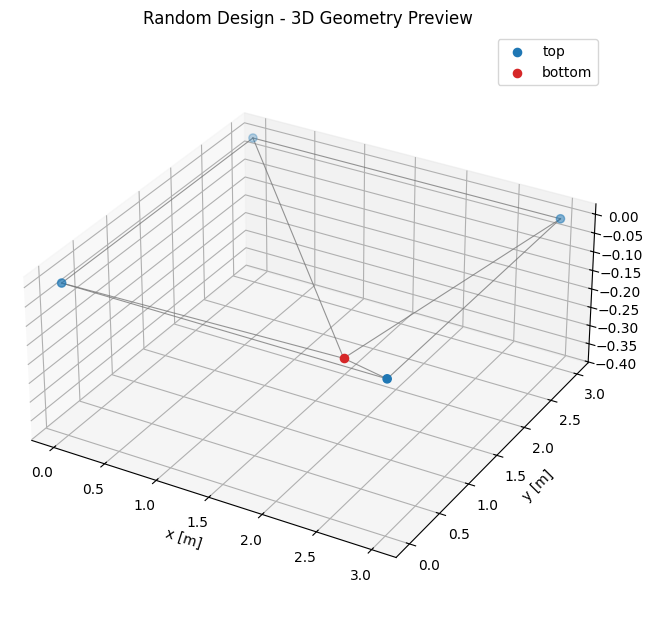

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Build a lookup so we can quickly fetch coordinates for each vertex id.
vertex_lookup = df_vertices.set_index("vertex_index")[["x", "y", "z", "layer"]].to_dict("index")

def _to_vertex_key(v):
    v_str = str(v)
    return v_str if v_str.startswith("v") else f"v{v_str}"

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

# Draw all members (edges)
for _, edge in df_edges.iterrows():
    v1 = _to_vertex_key(edge["V1"])
    v2 = _to_vertex_key(edge["V2"])

    if v1 not in vertex_lookup or v2 not in vertex_lookup:
        continue

    p1 = vertex_lookup[v1]
    p2 = vertex_lookup[v2]
    ax.plot3D(
        [p1["x"], p2["x"]],
        [p1["y"], p2["y"]],
        [p1["z"], p2["z"]],
        color="0.45",
        linewidth=0.8,
        alpha=0.75,
    )

# Draw nodes per layer for readability
df_top = df_vertices[df_vertices["layer"] == "top"]
df_bottom = df_vertices[df_vertices["layer"] == "bottom"]

ax.scatter3D(  # type: ignore
    np.asarray(df_top["x"]),
    np.asarray(df_top["y"]),
    np.asarray(df_top["z"]),
    s=35,
    c="#1f77b4",
    label="top",
)
ax.scatter3D(  # type: ignore
    np.asarray(df_bottom["x"]),
    np.asarray(df_bottom["y"]),
    np.asarray(df_bottom["z"]),
    s=35,
    c="#d62728",
    label="bottom",
)

ax.set_title("Random Design - 3D Geometry Preview")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]", labelpad=14)
ax.legend(loc="upper right")
ax.set_box_aspect((1, 1, 0.45))

# Keep extra space on the right so the z label is fully visible.
fig.subplots_adjust(left=0.06, right=0.90, bottom=0.08, top=0.93)
plt.show()

# GNN Placeholder

In [5]:
import pandas as pd
import numpy as np
import json
import config

# ==========================================
# 1. JOUW DUMMY DATA (Input van de workflow)
# ==========================================
data = df_vertices.copy()  # We gebruiken de gegenereerde vertices als input voor de mock GNN
df_geometry = pd.DataFrame(data)

# Edge index (start- en eindpunten van de balken)
edge_index_path = config.DATA_IO_PATH / "edge_index.json"
with open(edge_index_path, "r", encoding="utf-8") as f:
    edge_index_raw = json.load(f)

# Ondersteun zowel [[starts], [ends]] als dict-varianten uit eerdere scripts.
if isinstance(edge_index_raw, dict):
    start_nodes = edge_index_raw.get("start_nodes") or edge_index_raw.get("source") or edge_index_raw.get("V1")
    end_nodes = edge_index_raw.get("end_nodes") or edge_index_raw.get("target") or edge_index_raw.get("V2")
    if start_nodes is None or end_nodes is None:
        raise ValueError("edge_index.json mist vereiste keys voor start/end nodes.")
    edge_index = [start_nodes, end_nodes]
elif isinstance(edge_index_raw, list) and len(edge_index_raw) == 2:
    edge_index = edge_index_raw
else:
    raise ValueError("Onverwacht formaat voor edge_index.json; verwacht [starts, ends] of dict.")

# ==========================================
# 2. DE PLACEHOLDER SURROGATE MODEL FUNCTIE
# ==========================================
def voorspel_axiale_krachten_mock(df_nodes, edges, random_seed=42):
    """
    Placeholder voor het Graph Neural Network (GNN).
    Berekent per verbinding (edge) een fictieve axiale kracht in kN.
    """
    np.random.seed(random_seed)  # Zorgt voor reproduceerbare resultaten

    start_nodes = edges[0]
    end_nodes = edges[1]
    aantal_balken = len(start_nodes)

    voorspellingen = []

    for i in range(aantal_balken):
        idx_A = start_nodes[i]
        idx_B = end_nodes[i]

        # Haal coördinaten op uit het dataframe
        coord_A = df_nodes.iloc[idx_A][["x", "y", "z"]].values.astype(float)
        coord_B = df_nodes.iloc[idx_B][["x", "y", "z"]].values.astype(float)

        # Bereken de lengte van de balk (Euclidische afstand)
        lengte = np.linalg.norm(coord_B - coord_A)

        # --- MOCK LOGICA VOOR KRACHTEN ---
        # We genereren een willekeurige kracht (kN).
        # Balken in de bottom-layer simuleren we bijvoorbeeld vaak met druk (negatief).
        is_bottom_node = (df_nodes.iloc[idx_A]["layer"] == "bottom") or (df_nodes.iloc[idx_B]["layer"] == "bottom")

        if is_bottom_node:
            # Diagonale balken naar beneden krijgen vaak veel compressie (druk)
            kracht_kn = np.random.uniform(-60.0, -10.0)
        else:
            # Horizontale top-balken wisselen een beetje tussen trek en druk
            kracht_kn = np.random.uniform(-20.0, 30.0)

        # Voeg een beetje afhankelijkheid van de lengte toe (puur voor realisme in de mock)
        kracht_kn = kracht_kn * (lengte / 3.0)

        voorspellingen.append({
            "edge_id": f"e{i}",
            "V1": f"{idx_A}",
            "V2": f"{idx_B}",
            "length_m": round(lengte, 3),
            "axial_force_kn": round(kracht_kn, 2),
        })

    return pd.DataFrame(voorspellingen)

# ==========================================
# 3. UITVOEREN VAN DE INFERENCE STAP
# ==========================================
print("Start GNN Inference (Mock)...")
df_forces = voorspel_axiale_krachten_mock(df_geometry, edge_index)

print("\n✅ Axiale krachten succesvol voorspeld!")
print(df_forces.to_string(index=False))

Start GNN Inference (Mock)...

✅ Axiale krachten succesvol voorspeld!
edge_id V1 V2  length_m  axial_force_kn
     e0  0  1     3.000           -1.27
     e1  0  2     3.000           27.54
     e2  1  3     3.000           16.60
     e3  2  3     3.000            9.93
     e4  4  0     2.562          -44.58
     e5  4  1     2.632          -45.79
     e6  4  2     1.746          -33.24
     e7  4  3     1.847          -10.27


## Utilization

In [6]:
from structural_check import compute_utilization_outputs

# ==========================================
# STRUCTURAL CHECK (module-driven, reusable)
# ==========================================
required_vars = ["df_forces", "df_input_stock"]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise ValueError("Deze variabelen ontbreken uit eerdere cellen: " + ", ".join(missing_vars))

outputs = compute_utilization_outputs(
    df_forces=df_forces,
    df_input_stock=df_input_stock,
    gnn_marge=1.10,
 )

# Houd notebook-variabelen expliciet beschikbaar voor vervolgstappen
df_inventory = outputs["df_inventory"]
df_forces_local = outputs["df_forces_local"]
df_utilization_long = outputs["df_utilization_long"]
df_utilization_matrix = outputs["df_utilization_matrix"]
df_utilization_matrix_display = outputs["df_utilization_matrix_display"]
veilige_opties = outputs["veilige_opties"]
df_slots = outputs["df_slots"]

print(
    f"✅ Utilization berekend voor {len(df_forces_local)} staven en {len(df_inventory)} stock-elementen."
)
print(f"Totaal evaluaties: {len(df_utilization_long)}")
print(f"Veilige combinaties (utilization <= 1.0): {len(veilige_opties)}")

print("\nUtilization matrix (edge_id x Member_ID): utilization of inf indien niet haalbaar")
display(df_utilization_matrix_display)

print("\nTop 10 efficiënte veilige opties:")
display(
    veilige_opties[[
        "edge_id",
        "Member_ID",
        "Length",
        "Width",
        "Depth",
        "axial_force_kn",
        "length_m",
        "utilization",
    ]].head(10)
)

✅ Utilization berekend voor 8 staven en 20 stock-elementen.
Totaal evaluaties: 160
Veilige combinaties (utilization <= 1.0): 135

Utilization matrix (edge_id x Member_ID): utilization of inf indien niet haalbaar


Member_ID,NS_00009,NS_00027,NS_00061,NS_00069,NS_00095,NS_00124,NS_00164,NS_00203,NS_00204,NS_00224,NS_00245,NS_00257,NS_00290,NS_00291,RS_00001,RS_00009,RS_00013,RS_00015,RS_00016,RS_00017
edge_id,,,,,,,,,,,,,,,,,,,,
e0,0.017826,0.010696,0.010696,0.193277,0.010696,0.085901,0.001869,0.001257,0.432893,0.003120,0.065734,0.005031,0.013370,0.005031,0.157220,0.157220,0.157220,0.038553,0.028816,0.157220
e1,0.234418,0.140651,0.140651,0.703254,0.140651,0.312557,0.056260,0.039070,0.925334,0.087907,0.372092,0.117209,0.175813,0.117209,0.596700,0.596700,0.596700,0.277966,0.266384,0.596700
e2,0.141298,0.084779,0.084779,0.423893,0.084779,0.188397,0.033911,0.023550,0.557754,0.052987,0.224282,0.070649,0.105973,0.070649,0.359667,0.359667,0.359667,0.167547,0.160565,0.359667
e3,0.084523,0.050714,0.050714,0.253570,0.050714,0.112698,0.020286,0.014087,0.333644,0.031696,0.134164,0.042262,0.063392,0.042262,0.215150,0.215150,0.215150,0.100225,0.096049,0.215150
e4,0.484378,0.290627,0.290627,inf,0.290627,inf,0.063777,0.043288,inf,0.104083,inf,0.155853,0.363284,0.155853,inf,inf,inf,inf,0.760370,inf
e5,0.518636,0.311182,0.311182,inf,0.311182,inf,0.065780,0.044592,inf,0.107672,inf,0.162879,0.388977,0.162879,inf,inf,inf,inf,0.819323,inf
e6,0.235698,0.141419,0.141419,inf,0.141419,0.812559,0.045642,0.031303,inf,0.072794,0.648889,0.101269,0.176773,0.101269,inf,inf,inf,0.390474,0.310607,inf
e7,0.075839,0.045503,0.045503,0.625580,0.045503,0.278036,0.014166,0.009706,inf,0.022637,0.220063,0.031667,0.056879,0.031667,0.507739,0.507739,0.507739,0.131683,0.103357,0.507739



Top 10 efficiënte veilige opties:


,edge_id,Member_ID,Length,Width,Depth,axial_force_kn,length_m,utilization
10,e0,NS_00204,3300.0,38.0,100.0,-1.27,3.0,0.432893
0,e0,NS_00069,2100.0,50.0,100.0,-1.27,3.0,0.193277
14,e0,RS_00009,3000.0,50.0,150.0,-1.27,3.0,0.157220
15,e0,RS_00001,2850.0,50.0,150.0,-1.27,3.0,0.157220
18,e0,RS_00017,2950.0,50.0,150.0,-1.27,3.0,0.157220
19,e0,RS_00013,3100.0,50.0,150.0,-1.27,3.0,0.157220
6,e0,NS_00124,2400.0,50.0,225.0,-1.27,3.0,0.085901
9,e0,NS_00245,3600.0,63.0,150.0,-1.27,3.0,0.065734
17,e0,RS_00015,3600.0,70.0,230.0,-1.27,3.0,0.038553
16,e0,RS_00016,4050.0,80.0,210.0,-1.27,3.0,0.028816


# COST MATRIX

We now use one universal assignment formula for both reclaimed and new timber in the same cost matrix:

$$C_{i,j} = E_{embodied,i} + E_{prep,i} + E_{trans,i,j} + E_{waste,i,j} + E_{saw,i,j}$$

With:
- $E_{embodied,i} = V_{stock,i} \cdot M_{material,i}$ (from `ECC` in stock data)
- $E_{prep,i} = V_{stock,i} \cdot E_{prep}$
- $E_{trans,i,j} = \left(\frac{(V_{req}+V_{over})\cdot\rho}{1000}\right)\cdot D\cdot F_{trans}$
- $E_{waste,i,j} = V_{waste} \cdot E_{EoL}$
- $E_{saw,i,j} = P_{cut}$ when cutting is required, else 0

Interpretation by timber type:
- New timber: typically high `ECC`, usually low/zero preparation factor
- Reclaimed timber: `ECC` near 0, non-zero preparation factor

## Controle

In [7]:
from cost_calculation import prepare_stock_cost_inputs

# Strict validation + resolved inputs used by build_cost_matrix
df_stock_prepared = prepare_stock_cost_inputs(df_input_stock) # type: ignore

print("\n✅ Stock input gevalideerd voor de universele cost-formule.")
print("Preview van resolved kolommen:")
display(
    df_stock_prepared[[
        'Member_ID',
        'State',
        'ECC',
        'Bewerkingsfactor',
        'PreparationFactor_Resolved',
        'mean_density',
        'Transport_Dist',
        'Emmisiefactor'
    ]].head(10)
 )

✅ Rekenmodules succesvol gedefinieerd.

✅ Stock input gevalideerd voor de universele cost-formule.
Preview van resolved kolommen:


,Member_ID,State,ECC,Bewerkingsfactor,PreparationFactor_Resolved,mean_density,Transport_Dist,Emmisiefactor
0,NS_00069,0,150.0,0,0.0,420.0,150.81,0.1751
1,NS_00203,0,150.0,0,0.0,420.0,170.07,0.1764
2,NS_00009,0,150.0,0,0.0,420.0,162.35,0.1705
3,NS_00027,0,150.0,0,0.0,420.0,1623.38,0.1782
4,NS_00164,0,150.0,0,0.0,420.0,967.00,0.1751
5,NS_00290,0,150.0,0,0.0,420.0,338.21,0.1744
6,NS_00124,0,150.0,0,0.0,420.0,1608.37,0.1778
7,NS_00224,0,150.0,0,0.0,420.0,1021.96,0.1724
8,NS_00061,0,150.0,0,0.0,420.0,333.01,0.1702
9,NS_00245,0,150.0,0,0.0,420.0,282.55,0.1751


## Building of cost matrix

In [8]:
import importlib
import numpy as np
import pandas as pd
import config
import cost_calculation as cc

# Ensure latest src/cost_calculation.py is used in the active kernel
importlib.reload(cc)

build_cost_matrix = cc.build_cost_matrix
analyze_and_export_slot_logs = cc.analyze_and_export_slot_logs

# Diepte-analyse instellingen
target_slot_for_analysis = 'e7'
all_stock_ids = df_input_stock['Member_ID'].dropna().astype(str).tolist()

# Nieuwe constraint-instelling (utilization)
utilization_threshold = 1.0
utilization_threshold_sweep = [0.90, 1.00, 1.10]
utilization_matrix_for_cost = df_utilization_matrix if 'df_utilization_matrix' in globals() else None

print(f"🔍 Diepte-analyse gestart voor slot: {target_slot_for_analysis}")
print(f"📦 Aantal stock items in analyse: {len(all_stock_ids)}")

if utilization_matrix_for_cost is None:
    print("⚠️ Geen utilization-matrix gevonden; kostenmatrix draait zonder utilization-constraint.")
else:
    print(f"🧱 Utilization-constraint actief met gekozen drempel <= {utilization_threshold:.2f}")

    # Snelle sweep om effect op oplossingsruimte te tonen
    sweep_rows = []
    for thr in utilization_threshold_sweep:
        cm_sweep, _, _ = build_cost_matrix(
            df_slots,
            df_input_stock,
            target_stock_ids=None,
            df_utilization_matrix=utilization_matrix_for_cost,
            max_utilization_threshold=thr,
        )
        finite_mask = np.isfinite(cm_sweep)
        valid_count = int(finite_mask.sum())
        total_count = int(cm_sweep.size)
        valid_ratio = (valid_count / total_count) if total_count > 0 else 0.0
        mean_cost = float(np.nanmean(np.where(finite_mask, cm_sweep, np.nan))) if valid_count > 0 else np.nan

        sweep_rows.append({
            'threshold': thr,
            'valid_combinations': valid_count,
            'total_combinations': total_count,
            'valid_ratio': round(valid_ratio, 4),
            'mean_finite_cost': round(mean_cost, 3) if np.isfinite(mean_cost) else np.nan,
        })

    df_threshold_sweep = pd.DataFrame(sweep_rows).sort_values('threshold').reset_index(drop=True)
    print("\nVergelijking utilization-threshold sweep:")
    display(df_threshold_sweep)

# Bouw de matrix en log alle stock items (voor alle slots) met GEKOZEN threshold
cost_matrix, verrijkte_stock, df_logs = build_cost_matrix(
    df_slots,
    df_input_stock,
    target_stock_ids=all_stock_ids,
    df_utilization_matrix=utilization_matrix_for_cost,
    max_utilization_threshold=utilization_threshold,
)

# 3. Presentatie van het resultaat
# Maak er een DataFrame van, puur om het netjes te kunnen printen.
df_cost_matrix_display = pd.DataFrame(
    cost_matrix,
    index=[f"{row['edge_id']} ({row['Length_Req']:.0f}mm)" for _, row in df_slots.iterrows()],
    columns=verrijkte_stock['Member_ID'].tolist()
)

df_cost_matrix_display.to_csv(config.EXPORT_PATH / 'final_cost_matrix.csv', index=True)

# Diepte-analyse + export verplaatst naar cost_calculation.py
df_logs_slot, df_logs_slot_rs, analysis_export_path = analyze_and_export_slot_logs(
    df_logs=df_logs,
    target_slot_for_analysis=target_slot_for_analysis,
    all_stock_ids=all_stock_ids,
    export_dir=config.EXPORT_PATH,
    display_fn=display
)

print("\nPreview Cost Matrix (eerste 8 staven, eerste 5 inventaris-balken):")
print("(Let op: 'inf' betekent dat de inventaris-balk te klein is, utilization faalt, of anderszins wordt uitgesloten)\n")
print("=" * 80)
print(df_cost_matrix_display.iloc[:8, :5].round(2))

✅ Rekenmodules succesvol gedefinieerd.
🔍 Diepte-analyse gestart voor slot: e7
📦 Aantal stock items in analyse: 20
🧱 Utilization-constraint actief met gekozen drempel <= 1.00
Start generatie van de integrale CO2 Cost Matrix (nieuwe LCA-logica)...
✅ Matrix gegenereerd! Dimensies: 8 benodigde staven x 20 inventaris-balken.
📊 Aantal fysiek geldige combinaties gevonden: 85
🧱 Utilization-constraint actief met drempel <= 0.900
Start generatie van de integrale CO2 Cost Matrix (nieuwe LCA-logica)...
✅ Matrix gegenereerd! Dimensies: 8 benodigde staven x 20 inventaris-balken.
📊 Aantal fysiek geldige combinaties gevonden: 86
🧱 Utilization-constraint actief met drempel <= 1.000
Start generatie van de integrale CO2 Cost Matrix (nieuwe LCA-logica)...
✅ Matrix gegenereerd! Dimensies: 8 benodigde staven x 20 inventaris-balken.
📊 Aantal fysiek geldige combinaties gevonden: 88
🧱 Utilization-constraint actief met drempel <= 1.100

Vergelijking utilization-threshold sweep:


,threshold,valid_combinations,total_combinations,valid_ratio,mean_finite_cost
0,0.9,85,160,0.5312,14.741
1,1.0,86,160,0.5375,14.600
2,1.1,88,160,0.5500,14.292


Start generatie van de integrale CO2 Cost Matrix (nieuwe LCA-logica)...
✅ Matrix gegenereerd! Dimensies: 8 benodigde staven x 20 inventaris-balken.
📊 Aantal fysiek geldige combinaties gevonden: 86
🧱 Utilization-constraint actief met drempel <= 1.000

🔬 DIEPTE-ANALYSE: ALLE FACTOREN VOOR SLOT e7

Aantal RS-items voor e7: 6


,Stock_ID,Slot_ID,Status,Feasibility_Check,Utilization_Value,V_req_m3,V_over_m3,V_waste_m3,V_stock_m3,Embodied_CO2,Prep_CO2,Trans_CO2,Waste_CO2,Saw_CO2,TOTAL_Score
0,RS_00009,e7,✅,Passed,0.5077,0.013852,0.0,0.008648,0.0225,0.0,0.299,0.034,0.104,0.0194,0.457
1,RS_00001,e7,✅,Passed,0.5077,0.013852,0.0,0.007523,0.021375,0.0,0.284,0.22,0.09,0.0194,0.614
2,RS_00016,e7,✅,Passed,0.1034,0.03103,0.0,0.03701,0.06804,0.0,0.905,0.386,0.444,0.0194,1.754
3,RS_00015,e7,✅,Passed,0.1317,0.029737,0.0,0.028223,0.05796,0.0,0.771,0.046,0.339,0.0194,1.175
4,RS_00017,e7,✅,Passed,0.5077,0.013852,0.0,0.008273,0.022125,0.0,0.294,0.095,0.099,0.0194,0.508
5,RS_00013,e7,✅,Passed,0.5077,0.013852,0.0,0.009398,0.02325,0.0,0.309,0.006,0.113,0.0194,0.448



Volledige lijst (NS + RS):


,Stock_ID,Slot_ID,Status,Feasibility_Check,Utilization_Value,V_req_m3,V_over_m3,V_waste_m3,V_stock_m3,Embodied_CO2,Prep_CO2,Trans_CO2,Waste_CO2,Saw_CO2,TOTAL_Score
0,NS_00069,e7,✅,Passed,0.6256,0.009235,0.0,0.001265,0.0105,1.575,0.0,0.102,0.015,0.0194,1.712
1,NS_00203,e7,✅,Passed,0.0097,0.16623,0.0,0.10377,0.27,40.5,0.0,2.095,1.245,0.0194,43.859
2,NS_00009,e7,❌,GeometryOrLCA,0.0758,-,-,-,-,-,-,-,-,-,inf
3,NS_00027,e7,❌,GeometryOrLCA,0.0455,-,-,-,-,-,-,-,-,-,inf
4,NS_00164,e7,✅,Passed,0.0142,0.115438,0.0,0.053313,0.16875,25.312,0.0,8.209,0.64,0.0194,34.181
5,NS_00290,e7,✅,Passed,0.0569,0.03694,0.0,0.04106,0.078,11.7,0.0,0.915,0.493,0.0194,13.127
6,NS_00124,e7,✅,Passed,0.2780,0.020779,0.0,0.006221,0.027,4.05,0.0,2.496,0.075,0.0194,6.640
7,NS_00224,e7,✅,Passed,0.0226,0.07388,0.0,0.05812,0.132,19.8,0.0,5.467,0.697,0.0194,25.984
8,NS_00061,e7,❌,GeometryOrLCA,0.0455,-,-,-,-,-,-,-,-,-,inf
9,NS_00245,e7,✅,Passed,0.2201,0.017454,0.0,0.016566,0.03402,5.103,0.0,0.363,0.199,0.0194,5.684



💾 Diepte-analyse geëxporteerd naar: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\diepte_analyse_e7.csv

Preview Cost Matrix (eerste 8 staven, eerste 5 inventaris-balken):
(Let op: 'inf' betekent dat de inventaris-balk te klein is, utilization faalt, of anderszins wordt uitgesloten)

             NS_00069  NS_00203  NS_00009  NS_00027  NS_00164
e0 (3000mm)       inf     43.90       inf       inf       inf
e1 (3000mm)       inf     43.90       inf       inf       inf
e2 (3000mm)       inf     43.90       inf       inf       inf
e3 (3000mm)       inf     43.90       inf       inf       inf
e4 (2562mm)       inf     43.90       inf       inf     36.82
e5 (2632mm)       inf     43.90       inf       inf     37.08
e6 (1746mm)       inf     43.85       inf       inf     33.81
e7 (1847mm)      1.71     43.86       inf       inf     34.18


# MATCHING ALGORITHM / ILP

In [10]:
import pulp
import numpy as np
import pandas as pd

# ==========================================
# CEL 4: TOEPASSING VAN HET OPTIMALISATIE ALGORITME (MILP)
# ==========================================
print("Start MILP Optimizer voor definitieve toewijzing...")

# 1. DATA KOPPELEN VANUIT VORIGE SCRIPTS
# Haal de namen op uit de DataFrames van de vorige cellen
stock_items = verrijkte_stock['Member_ID'].tolist()
construction_slots = df_slots['edge_id'].tolist()

# Dynamische categorisatie (kijkt naar 'NS' en 'RS' in de Member_ID)
new_items = [item for item in stock_items if 'NS' in item]
reclaimed_items = [item for item in stock_items if 'RS' in item]

print(f"📊 Inventaris: {len(reclaimed_items)} Reclaimed, {len(new_items)} New elementen.")
print(f"📐 Constructie vereist: {len(construction_slots)} staven.")

# 2. FILTEREN VAN DE COST MATRIX (Sparse Matrix Maken)
# We maken alleen combinaties aan die fysiek passen (waar de cost NIET oneindig is)
valid_matches = []
costs = {}

for i, slot_id in enumerate(construction_slots):
    for j, stock_id in enumerate(stock_items):
        cost = cost_matrix[i, j]
        # Als de cost niet 'inf' is, is het een geldige match!
        if cost != np.inf:
            valid_matches.append((stock_id, slot_id))
            costs[(stock_id, slot_id)] = cost

print(f"⚡ Aantal geldige combinaties voor de solver gereduceerd tot: {len(valid_matches)}")

# 3. HET MODEL OPZETTEN
prob = pulp.LpProblem("Reclaimed_Timber_Matching", pulp.LpMinimize)

# 4. DECISION VARIABLES
# We maken uitsluitend 'knoppen' aan voor de combinaties die kunnen passen
x = pulp.LpVariable.dicts("Match", valid_matches, 0, 1, pulp.LpBinary)

# 5. OBJECTIVE FUNCTION (Doel: Minimaliseer de totale CO2 penalty)
prob += pulp.lpSum([x[match] * costs[match] for match in valid_matches])

# 6. CONSTRAINTS (De Regels)

# Regel A: Elke staaf in de constructie MOET precies 1 balk toegewezen krijgen
for slot_id in construction_slots:
    # Zoek alle balken die überhaupt passen op dit slot
    valid_stock_for_slot = [stock_id for (stock_id, s_id) in valid_matches if s_id == slot_id]

    if not valid_stock_for_slot:
        print(f"⚠️ FATALE FOUT: Slot {slot_id} heeft GEEN ENKELE fysiek passende balk in de hele voorraad!")
    else:
        prob += pulp.lpSum([x[(stock_id, slot_id)] for stock_id in valid_stock_for_slot]) == 1

# Regel B: Reclaimed hout is uniek (Max 1x gebruiken)
for stock_id in reclaimed_items:
    valid_slots_for_stock = [s_id for (s_id_tuple, s_id) in valid_matches if s_id_tuple == stock_id]
    if valid_slots_for_stock:
        prob += pulp.lpSum([x[(stock_id, slot_id)] for slot_id in valid_slots_for_stock]) <= 1

# Regel C: Nieuw hout mag oneindig gebruikt worden (Limiet = aantal benodigde staven)
for stock_id in new_items:
    valid_slots_for_stock = [s_id for (s_id_tuple, s_id) in valid_matches if s_id_tuple == stock_id]
    if valid_slots_for_stock:
        prob += pulp.lpSum([x[(stock_id, slot_id)] for slot_id in valid_slots_for_stock]) <= len(construction_slots)

# ==========================================
# 7. OPLOSSEN EN RESULTATEN
# ==========================================
prob.solve()

print("\n" + "="*50)
print(f"STATUS OPLOSSING: {pulp.LpStatus[prob.status]}")
print("="*50)

if pulp.LpStatus[prob.status] == 'Optimal':
    total_cost = pulp.value(prob.objective)

    # Sla de winnende combinaties op in een overzichtelijke lijst
    results = []
    for j in construction_slots:
        for i in stock_items:
            match = (i, j)
            if match in x and x[match].varValue == 1:
                # Gebruik dezelfde kolomnamen als in de merge-stap
                results.append({'edge_id': j, 'assigned_timber': i, 'CO2_Penalty': round(costs[match], 2)})

    df_results = pd.DataFrame(results)

    print(f"\n✅ Het optimale ontwerp is gevonden met een totale CO2 penalty van {total_cost:.2f} kg!")

    # ==========================================
    # 8. MERGEN MET DE ORIGINELE EDGE MATRIX
    # ==========================================
    # We gebruiken pd.merge om de nieuwe 'assigned_timber' kolom naast je bestaande V1/V2 kolommen te plakken
    df_final_edges = pd.merge(df_slots, df_results[['edge_id', 'assigned_timber']], on='edge_id', how='left')

    print("\nDefinitieve Hout-Toewijzing:")
    print("-" * 50)
    print(df_results.to_string(index=False))

    # Optioneel: Exporteer dit naar CSV om in Grasshopper te kleuren
    # df_final_edges.to_csv('definitieve_toewijzing.csv', index=False)

else:
    print("❌ Het algoritme kon geen oplossing vinden. Waarschijnlijk is je voorraad niet toereikend voor de opgevraagde constructie.")

Start MILP Optimizer voor definitieve toewijzing...
📊 Inventaris: 6 Reclaimed, 14 New elementen.
📐 Constructie vereist: 8 staven.
⚡ Aantal geldige combinaties voor de solver gereduceerd tot: 86

STATUS OPLOSSING: Optimal

✅ Het optimale ontwerp is gevonden met een totale CO2 penalty van 22.70 kg!

Definitieve Hout-Toewijzing:
--------------------------------------------------
edge_id assigned_timber  CO2_Penalty
     e0        NS_00204         2.62
     e1        RS_00013         0.35
     e2        RS_00009         0.35
     e3        NS_00204         2.62
     e4        NS_00290        13.31
     e5        RS_00016         1.76
     e6        RS_00015         1.19
     e7        RS_00017         0.51


# EXPORT

This is where the best parameters of the sctructure are exported, this is done in a format that can be used by grasshopper script to translate it into geometry

In [ ]:
# @title Export geometry + assigned stock
import pandas as pd
import config

# ==========================================
# 8. EXPORT VAN GEOMETRIE + MATCHING RESULTATEN
# ==========================================
# Parameters/keuzes
EXPORT_PREFIX = "optimum"              # bv. "optimum", "run01", ...
EXPORT_UNASSIGNED_AS = "UNASSIGNED"    # label voor edges zonder match
DROP_UNASSIGNED_EDGES = False           # True = alleen gematchte edges exporteren

print("\n📦 Exporteren van vertices en edges met toegewezen stock...")

# --- 1) Validatie van vereiste data uit eerdere cellen ---
required_vars = ["df_vertices", "df_edges", "df_results"]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise ValueError(
        "Deze variabelen ontbreken uit eerdere cellen: " + ", ".join(missing) + 
        ". Run eerst geometry, matching en ILP-cellen."
    )

# --- 2) Maak edge export met assigned_timber ---
df_edges_export = df_edges.copy()
df_edges_export = pd.merge(
    df_edges_export,
    df_results[["edge_id", "assigned_timber", "CO2_Penalty"]],
    on="edge_id",
    how="left"
 )
df_edges_export["assigned_timber"] = df_edges_export["assigned_timber"].fillna(EXPORT_UNASSIGNED_AS)
df_edges_export["CO2_Penalty"] = df_edges_export["CO2_Penalty"].fillna(0)

if DROP_UNASSIGNED_EDGES:
    df_edges_export = df_edges_export[df_edges_export["assigned_timber"] != EXPORT_UNASSIGNED_AS].copy()

# --- 3) Bestandspaden opbouwen ---
pad_vertices = config.EXPORT_PATH / f"{EXPORT_PREFIX}_vertices.csv"
pad_edges = config.EXPORT_PATH / f"{EXPORT_PREFIX}_edges_with_stock.csv"

# --- 4) Exporteren ---
df_vertices.to_csv(pad_vertices, index=False)
df_edges_export.to_csv(pad_edges, index=False)

# --- 5) Samenvatting ---
n_total = len(df_edges_export)
n_matched = int((df_edges_export["assigned_timber"] != EXPORT_UNASSIGNED_AS).sum())
print(f"✅ Vertices geëxporteerd: {len(df_vertices)} -> {pad_vertices}")
print(f"✅ Edges geëxporteerd: {n_total} (matched: {n_matched}) -> {pad_edges}")

print("\nPreview edges + assigned_timber:")
display(df_edges_export.head(10))